# Comparing the results of multiple cryptocurrencies


## Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import random

In [2]:
from os import listdir
from os.path import isfile, join


Importing the collected data

In [3]:
#from google.colab import files
#uploaded = files.upload()
#%ls

In [4]:
def plot_time_series(predicted, true, n_training, filename):
  """
  Plot the time series
  """
  plt.figure(figsize=(16,10)) #plotting
  plt.axvline(x=n_training, color="#ffd166", linestyle='-') #size of the training set

  plt.plot(predicted, label='Predicted Price', color="#118ab2") #predicted plot
  plt.plot(true, label='True Price', color="#06d6a0") #actual plot

  plt.title('Time-Series Prediction', fontsize=16)
  plt.xlabel('Time', fontsize=14)
  plt.ylabel('Price', fontsize=14)

  plt.xlim(0)
  plt.legend()
  plt.show()
  #plt.savefig(filename) 

## LSTM Model


### Model Definition

In [5]:
class LSTMCustom(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(LSTMCustom, self).__init__()
        self.num_classes = num_classes #number of classes
        self.num_layers = num_layers #number of layers
        self.input_size = input_size #input size
        self.hidden_size = hidden_size #hidden state
        self.seq_length = seq_length #sequence length

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True) #lstm

        #self.fc_1 =  nn.Linear(hidden_size, 128) #fully connected 1
        #self.fc = nn.Linear(128, num_classes) #fully connected last layer

        #self.relu = nn.ReLU()

        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self,x):
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #hidden state
        c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #internal state
        # Propagate input through LSTM
        output, (hn, cn) = self.lstm(x, (h_0, c_0)) #lstm with input, hidden, and internal state

        #hn = hn.view(-1, self.hidden_size) #reshaping the data for Dense layer next
        #out = self.relu(hn)
        #out = self.fc_1(out) #first Dense
        #out = self.relu(out) #relu
        #out = self.fc(out) #Final Output
        
        out = self.fc(output[:,-1,:])
        return out

Model Parameters

In [6]:
num_epochs = 200 #until loss stops dropping
learning_rate = 0.01 #0.001 lr (.001-0.03)

#this needs to change with x, df_x_ss to change input
input_size = 22 #number of features
hidden_size = 32 #number of features in hidden state (try 16-256)
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

look_back = 24 #sliding window, how many of the previous feature vectors are included in the input


In [7]:
criterion = torch.nn.MSELoss()  # mean-squared error for regression

### Training Each Crypto

In [8]:
mm = MinMaxScaler()
ss = StandardScaler()

In [9]:
def train_test_split_tensor(x, y):
  """
  Custom train/test splitting
  TODO: maybe shorten code by using sklearn.preprocessing.train_test_split
  """
  cutoff = round(x.shape[0] * 0.8)

  # split into train and test
  x_train = x[:cutoff, :]
  x_test = x[cutoff:,:]
  y_train = y[:cutoff, :]
  y_test = y[cutoff:, :]

  # convert to tensor
  x_train = Variable(torch.Tensor(x_train))
  x_test = Variable(torch.Tensor(x_test))
  y_train = Variable(torch.Tensor(y_train))
  y_test = Variable(torch.Tensor(y_test)) 
  
  return x_train, x_test, y_train, y_test, cutoff

In [10]:
def process_data(df):

  # split into x and y

  #set this range to choose input parameters (do it in the main loop for df_x_ss as well)
  x = df.iloc[:, :-2]
  y = df.iloc[look_back:,-1:]
  y_mm = mm.fit_transform(y)
  x_raw = ss.fit_transform(x)

  x_2d = []
  for index in range(len(x_raw)):
    x_2d.append(x_raw[index - look_back:index+1])
  x_2d = np.array(x_2d[look_back:])

  # get train and test split and convert to tensors
  x_train, x_test, y_train, y_test, cutoff = train_test_split_tensor(x_2d, y_mm)

  return x_train, x_test, y_train, y_test, cutoff

In [11]:
def train(df, lstm):
  """
  Train the lstm
  """
  x_train, x_test, y_train, y_test, cutoff = process_data(df)

  for epoch in range(num_epochs):
    outputs = lstm.forward(x_train) #forward pass
    optimizer.zero_grad() #caluclate the gradient, manually setting to 0
  
    # obtain the loss function
    loss = criterion(outputs, y_train)
  
    loss.backward() #calculates the loss of the loss function
  
    optimizer.step() #improve from loss, i.e backprop
    if epoch % 50 == 0: 
      print("Epoch: %d, loss: %1.5f" % (epoch, loss.item())) 

  return lstm, cutoff

In [12]:
def classify(predict, direction):
    results = []
    #multiplication by 1+- small value if we want a neutral range, needs to be changed in split_lags to set the price direction feature as the same
    for i in range(len(predict)):
        if (predict[i] > predict[i-1]*1.0):
            results.append("positive")
        elif (predict[i] <= predict[i-1]*1.0):
            results.append("negative")
        else:
            results.append("neutral")
    results.append("neutral")
    totalcorrect = neutralcount = neutralcorrect = positivecorrect = negativecorrect = positivecount = negativecount = neutralprediction = 0
    for i in range(len(predict)):
        if results[i] == "neutral":
            neutralprediction += 1
        if direction[i] == "positive":
            positivecount += 1
        elif direction[i] == "negative":
            negativecount += 1
        elif direction[i] == "neutral":
            neutralcount += 1
        if results[i] == direction[i]:
            totalcorrect += 1
            if results[i] == "negative":
                negativecorrect += 1
            elif results[i] == "positive":
                positivecorrect += 1
            elif results[i] == "neutral":
                neutralcorrect += 1

    print("% positive: ", positivecount/len(predict))
    print("% negative: ", negativecount/len(predict))
    #print("% neutral: ", neutralcount/len(predict))
    print(f"positive correct: {positivecorrect}/{positivecount} ", positivecorrect/positivecount)
    print(f"negative correct: {negativecorrect}/{negativecount} ", negativecorrect/negativecount)
    #print("neutral correct: ", neutralcorrect/neutralcount)

    return totalcorrect/len(predict)

binance-coinhourly.csv
Epoch: 0, loss: 0.00336
Epoch: 50, loss: 0.00002
Epoch: 100, loss: 0.00001
Epoch: 150, loss: 0.00000
% positive:  0.5218673218673219
% negative:  0.4781326781326781
positive correct: 547/1062  0.5150659133709982
negative correct: 450/973  0.4624871531346352
test accuracy: 0.48992628992628995


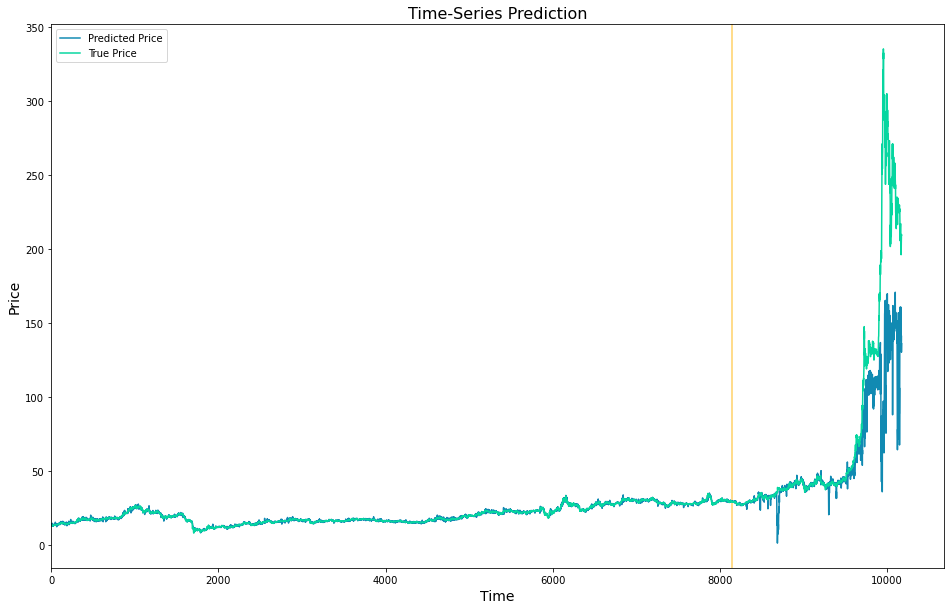

bitcoin-cashhourly.csv
Epoch: 0, loss: 0.02204
Epoch: 50, loss: 0.00010
Epoch: 100, loss: 0.00005
Epoch: 150, loss: 0.00004
% positive:  0.5095823095823095
% negative:  0.4904176904176904
positive correct: 538/1037  0.5188042430086789
negative correct: 480/998  0.48096192384769537
test accuracy: 0.5002457002457003


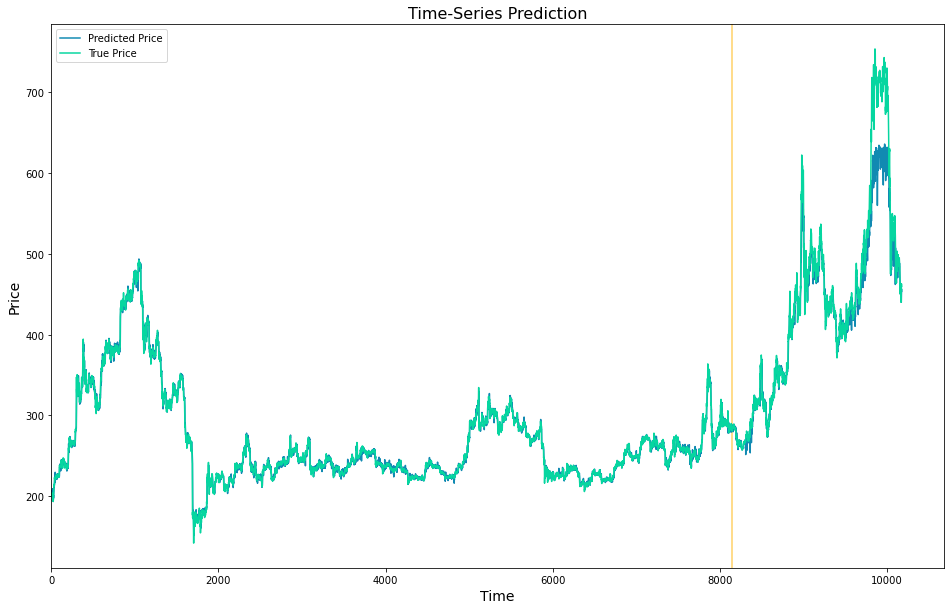

bitcoinhourly.csv
Epoch: 0, loss: 0.01483
Epoch: 50, loss: 0.00036
Epoch: 100, loss: 0.00007
Epoch: 150, loss: 0.00003
% positive:  0.5267813267813268
% negative:  0.4732186732186732
positive correct: 544/1072  0.5074626865671642
negative correct: 437/963  0.4537902388369678
test accuracy: 0.48206388206388207


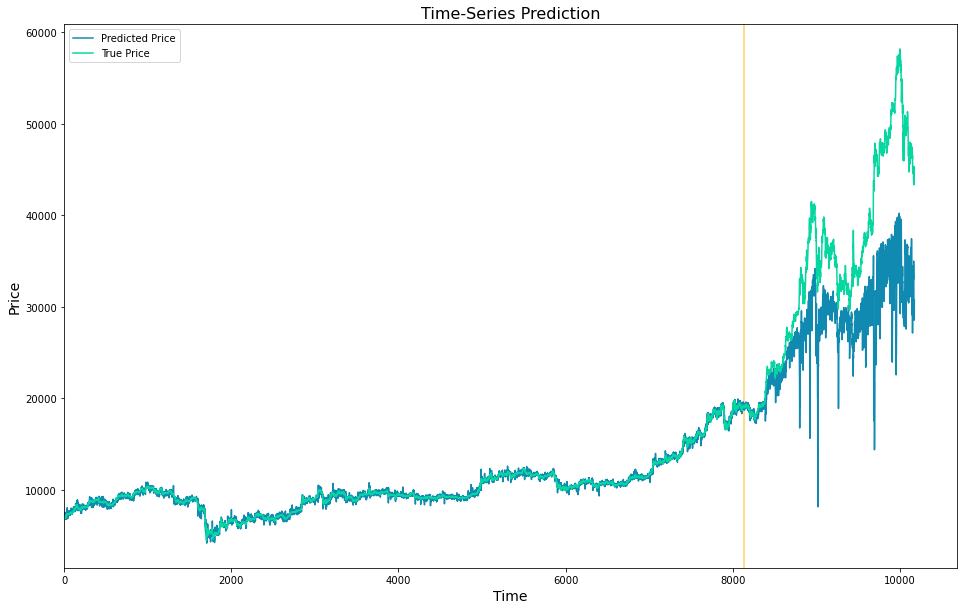

cardanohourly.csv
Epoch: 0, loss: 0.01456
Epoch: 50, loss: 0.00011
Epoch: 100, loss: 0.00002
Epoch: 150, loss: 0.00001
% positive:  0.5115479115479116
% negative:  0.48845208845208843
positive correct: 564/1041  0.5417867435158501
negative correct: 455/994  0.45774647887323944
test accuracy: 0.5007371007371008


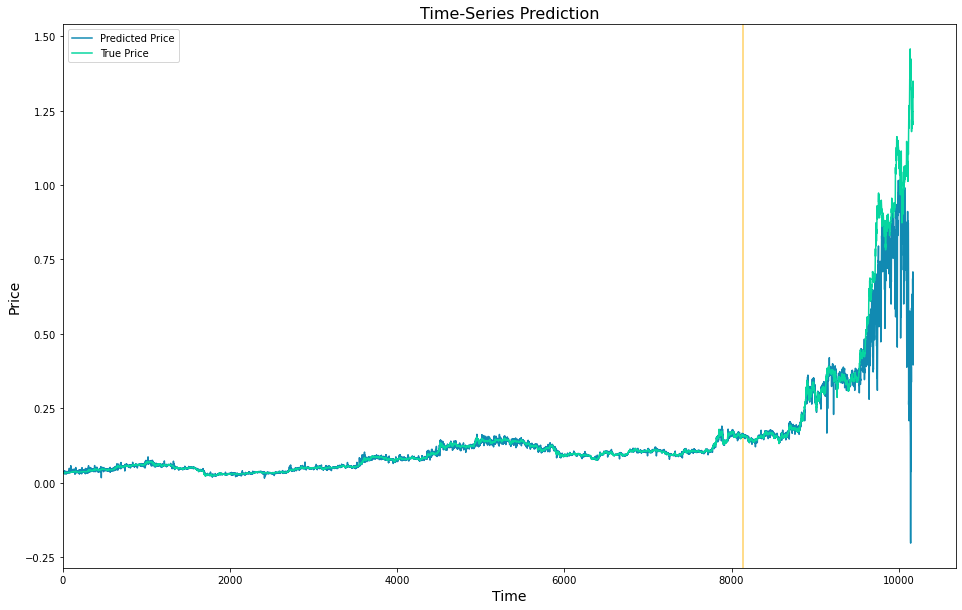

chainlinkhourly.csv
Epoch: 0, loss: 0.01772
Epoch: 50, loss: 0.00007
Epoch: 100, loss: 0.00003
Epoch: 150, loss: 0.00002
% positive:  0.5027027027027027
% negative:  0.4972972972972973
positive correct: 483/1023  0.47214076246334313
negative correct: 481/1012  0.475296442687747
test accuracy: 0.47371007371007373


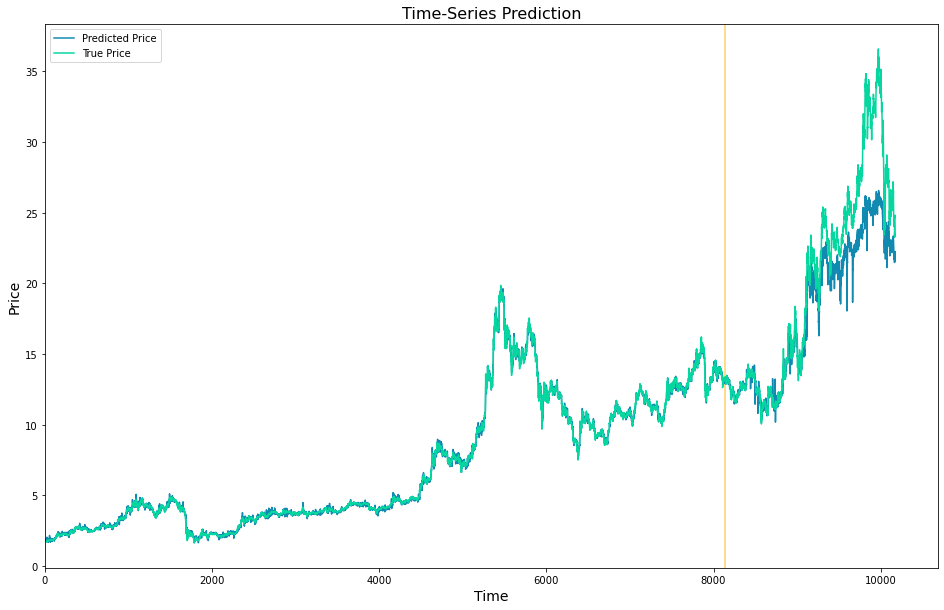

ethereumhourly.csv
Epoch: 0, loss: 0.00335
Epoch: 50, loss: 0.00029
Epoch: 100, loss: 0.00005
Epoch: 150, loss: 0.00002
% positive:  0.515970515970516
% negative:  0.48402948402948404
positive correct: 566/1050  0.539047619047619
negative correct: 448/985  0.4548223350253807
test accuracy: 0.4982800982800983


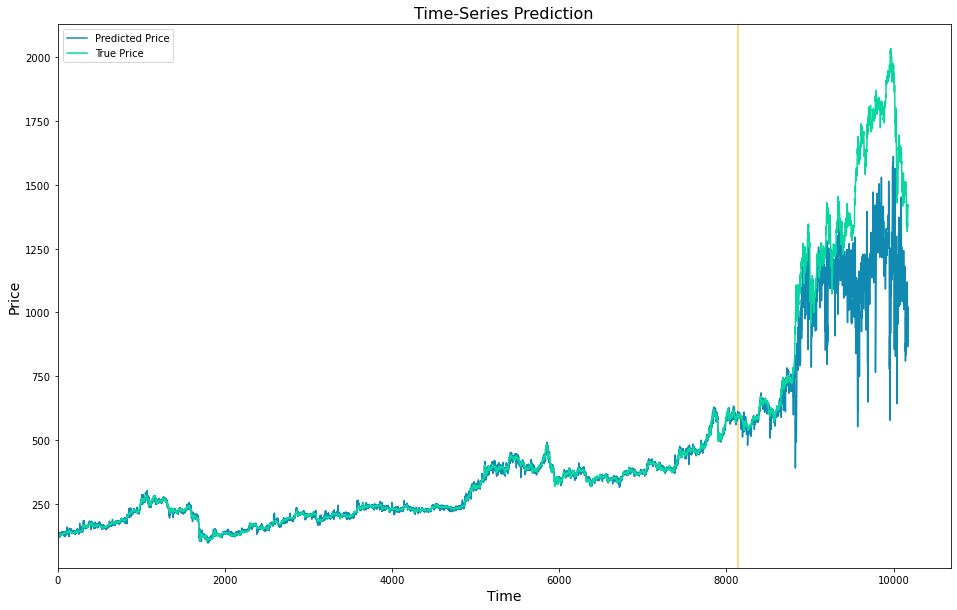

litecoinhourly.csv
Epoch: 0, loss: 0.00794
Epoch: 50, loss: 0.00006
Epoch: 100, loss: 0.00002
Epoch: 150, loss: 0.00002
% positive:  0.5085995085995086
% negative:  0.4914004914004914
positive correct: 539/1035  0.5207729468599034
negative correct: 497/1000  0.497
test accuracy: 0.509090909090909


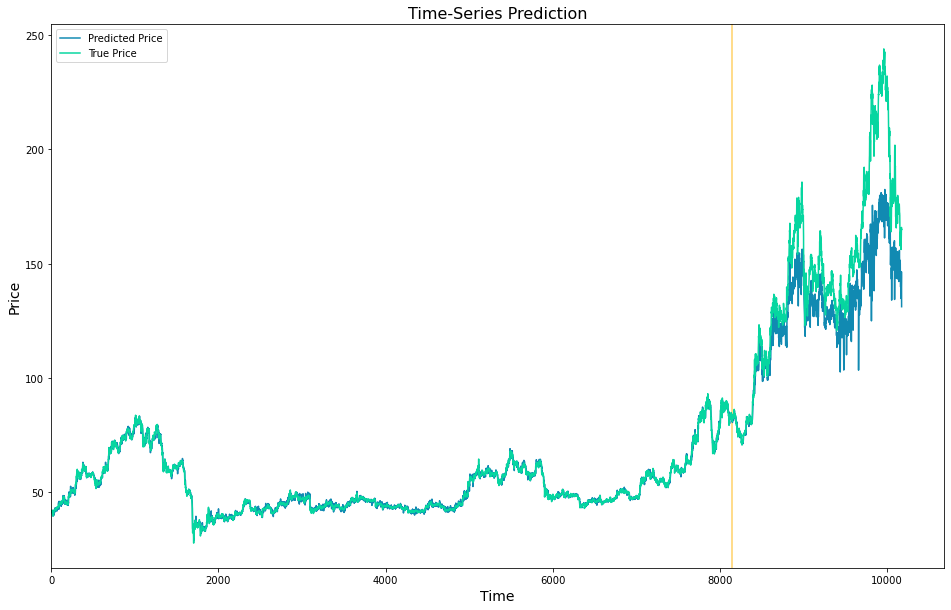

ripplehourly.csv
Epoch: 0, loss: 0.05033
Epoch: 50, loss: 0.00018
Epoch: 100, loss: 0.00008
Epoch: 150, loss: 0.00006
% positive:  0.48157248157248156
% negative:  0.5184275184275184
positive correct: 478/980  0.48775510204081635
negative correct: 510/1055  0.4834123222748815
test accuracy: 0.4855036855036855


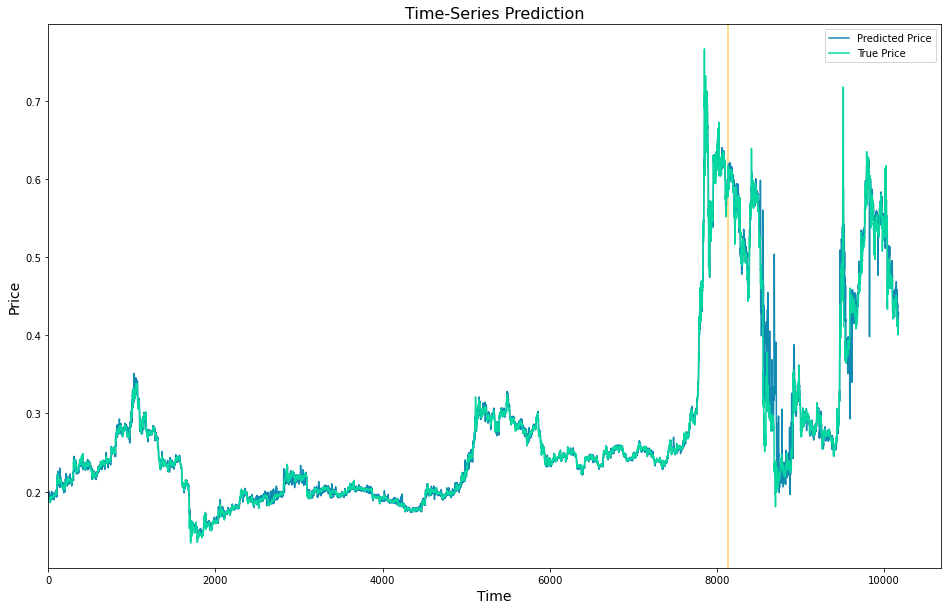

stellarhourly.csv
Epoch: 0, loss: 0.01007
Epoch: 50, loss: 0.00007
Epoch: 100, loss: 0.00002
Epoch: 150, loss: 0.00001
% positive:  0.47665847665847666
% negative:  0.5233415233415234
positive correct: 515/970  0.5309278350515464
negative correct: 551/1065  0.5173708920187794
test accuracy: 0.5238329238329238


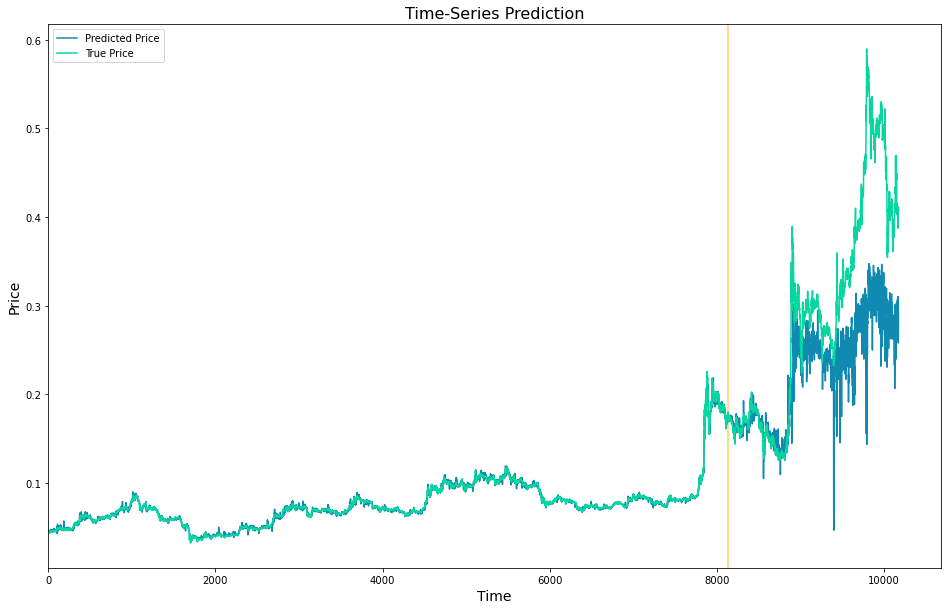

In [13]:

#current processed data in datatest and dataOriginaltest
dir_path = "dataLSTM/mar14/"
file_list = [f for f in listdir(dir_path) if isfile(join(dir_path, f))]
#file_list = [f for f in listdir() if isfile(f)]

file_endings = ["5m.csv", "hourly.csv", "daily.csv", "2h.csv", "30m.csv", "5mJune.csv", "15min.csv"]

# FIXME: move to each fileending?
file_ending = file_endings[1]
results = []
for filename in [name for name in file_list if file_ending in name]:
  crypto_name = filename.replace(file_ending, "")
  print(filename)
  
  df = pd.read_csv(dir_path + filename)
  #print(df.head())

  # define LSTM class
  lstm = LSTMCustom(num_classes, input_size, hidden_size, num_layers, df.shape[1]) 
  optimizer = torch.optim.Adam(lstm.parameters(), lr=learning_rate) 

  lstm, cutoff = train(df, lstm)

  #set this range to choose input parameters
  df_x_ss = ss.transform(df.iloc[:, :-2]) #old transformers


  df_x_2d = []
  for index in range(len(df_x_ss)):
    df_x_2d.append(df_x_ss[index-look_back:index])
  
  df_x_2d = df_x_2d[look_back:]
  df_y_mm = mm.transform(df.iloc[look_back:, -1:]) #old transformers

  df_x_2d = np.array(df_x_2d)
  df_x_ss = Variable(torch.Tensor(df_x_2d)) #converting to Tensors
  df_y_mm = Variable(torch.Tensor(df_y_mm))

  train_predict = lstm(df_x_ss) #forward pass
  data_predict = train_predict.data.numpy() #numpy conversion
  
  dataY_plot = df_y_mm.data.numpy()

  data_predict = mm.inverse_transform(data_predict) #reverse transformation

  test_accuracy = classify(data_predict[cutoff:], df.iloc[cutoff+look_back:].priceDirection.reset_index(drop=True))
  print(f"test accuracy: {test_accuracy}")

  dataY_plot = mm.inverse_transform(dataY_plot)

  plot_name = f"{crypto_name}{file_ending}.png"
  plot_time_series(data_predict, dataY_plot, cutoff, plot_name)

  #model_name = f"{crypto_name}.pth"
  #torch.save(lstm.state_dict(), model_name)

  results.append([filename, test_accuracy])

In [14]:
resultsdf = pd.DataFrame(results)
print("input size: ", input_size)
print("epochs: ", num_epochs)
print("learning rate: ", learning_rate)
print("hidden size: ", hidden_size)
print("look back: ", look_back)
print(resultsdf)

input size:  22
epochs:  200
learning rate:  0.01
hidden size:  32
look back:  24
                        0         1
0  binance-coinhourly.csv  0.489926
1  bitcoin-cashhourly.csv  0.500246
2       bitcoinhourly.csv  0.482064
3       cardanohourly.csv  0.500737
4     chainlinkhourly.csv  0.473710
5      ethereumhourly.csv  0.498280
6      litecoinhourly.csv  0.509091
7        ripplehourly.csv  0.485504
8       stellarhourly.csv  0.523833
